# Project evaluation: Human-Centered Evaluation of Your Collaborative Agent

## **Important! Make a copy of this file...**
- [ ] This is a Colab template that you should not modify.
- [ ] Please make your own copy, by selecting e.g. `File > Save a copy in Drive`.
- [ ] Afterwards, make your file identifiable by renaming it to be `AIAgents-S26-youragenthere.ipynb`.



## Overview

In this assignment, you will evaluate your team project agent using two complementary methods:

- Intrinsic Evaluation — an automated evaluation (e.g., LLM-as-a-judge or code-based metric).
- Extrinsic Evaluation — a small-scale user study with real participants outside the class.

You will design, implement, and analyze these evaluations, then summarize your work in a structured write-up that includes both your results and reflections.

You will also propose one additional evaluation type you could run in the future (but won’t conduct for this assignment).

## Learning Objectives:
By the end of this assignment, you should be able to:

- Apply intrinsic metrics for automated performance measurement of conversational agents.
- Design and conduct a small-scale user study to capture user experience and task outcomes.
- Use the SPHERE Evaluation Card to communicate your evaluation design clearly.
- Draw evidence-based conclusions about an agent’s performance.

## Grading Rubric (Total: 100 points)

| Category | Points | Description |
|----------|--------|-------------|
| **Intrinsic Evaluation Design & Implementation** | 30 | 1–3 well-defined metrics tied to agent goals; correct LLM/code implementation; tested on ≥3 diverse examples with meaningful results. |
| **Extrinsic Evaluation Design & Execution** | 30 | Clear, realistic protocol; relevant participants/tasks; both quantitative and qualitative data collected and documented. |
| **SPHERE Evaluation Cards** | 5 | Two completed JSON cards (intrinsic & extrinsic); accurate, detailed, and aligned with evaluation methods. |
| **Results & Conclusions** | 20 | Clear presentation of results; at least one supported conclusion per evaluation with convincing evidence. |
| **Proposed Additional Evaluation** | 10 | Thoughtful and relevant; clear design outline and strong justification for future use. |
| **Clarity & Effort** | 5 | Well-organized, clearly written submission demonstrating strong effort and attention to detail. |




## Step 1: Setup

(You'll need some kind of setup code in your repo, here is an example)

Here, we will do a similar round of setup as in Assignment 1, installing necessary packages for modeling calling. It also copies over the interactive interface I hacked in A1.
**If there are code you would like to reuse, please feel free to copy over here.**

In [ ]:
!pip install anthropic judges "instructor[anthropic]" requests pandas matplotlib

In [ ]:
import os, json, time, requests
from textwrap import dedent
from anthropic import Anthropic

# Colab: pull from Secrets and set the env var
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
except (ImportError, Exception):
    pass  # not in Colab, or secret not set — falls through to the assert

assert os.environ.get("ANTHROPIC_API_KEY"), "Set ANTHROPIC_API_KEY before running."

client = Anthropic()
MODEL = "claude-sonnet-4-20250514"



## Step 2: Load the agent to test

(This is just an example, you will probably want to write this in your project repo as its own script, just document what scripts to run and commit outputs from them and link the files here/in your project Readme)

Here, you will set up your AWS and Huggingface Access Keys to reload the agent you created in Assignment 1. This will be the agent you test.

In [ ]:
!pip install anthropic

In [ ]:
import os
# set the keys to be in the env

from google.colab import userdata
os.environ['AWS_ACCESS_KEY_ID'] = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
os.environ["AWS_REGION_NAME"] = "us-east-1"

In [ ]:
import os
from huggingface_hub import login

from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

login(token=os.getenv("HF_TOKEN"))

## Step 3: Intrinsic evaluation

- Define **1–3 metrics** that capture an important aspect of your agent’s performance (e.g., factual accuracy, task completeness, response brevity, trade-off clarity).
- Implement these metrics using either:
  - **LLM-as-a-judge** (provide prompt & scoring rubric to an LLM, return numerical score)
  - **Code-based scoring** (string matching, word count, time to completion, etc.)
- Test the metrics on **at least 3 example interactions** with your agent
  - This one will require you to interact with your agent for at least three times, ideally with you simulating diverse personas to create diverse use cases -- Think of how they would represent different use scenarios or edge cases!
  - If you feel motivated, you could also try creating simulated LLM personas that would have simulated conversation with the agent, similar to [Co-Gym](https://arxiv.org/abs/2412.15701).
- Save both the metric definitions and results.
- To submit this part, I recommend you just link give a link to a branch on your project's github repository.


Below is some example code implementing the same verifier using LLM-as-judge and rule-based python function (though the rule-based method would miss edge cases for sure). The default starter implementation provided below uses the [Judges](https://github.com/quotient-ai/judges) library, but you can also create it from scratch or use another library. Some useful reference links, from the Huggingface Cookbook:
- [Using LLM-as-a-judge 🧑‍⚖️ for an automated and versatile evaluation](https://huggingface.co/learn/cookbook/en/llm_judge) -- A general walkthrough on LLM-as-judge (check it out / see also the documentation)
- [Evaluating AI Search Engines with judges - the open-source library for LLM-as-a-judge evaluators ⚖️](https://huggingface.co/learn/cookbook/en/llm_judge_evaluating_ai_search_engines_with_judges_library) -- More examples on the `Judges` library.

### TODO: Please fill in your intrinsic evaluation design here.

## Intrinsic Evaluation Design

### Metric 1: Deficit-language compliance
- **How it is computed:** A rule-based Python function scans the agent response for deficit-based or overly negative phrases such as “you struggle with,” “your weakness,” “despite your ADHD,” “compensate,” “executive function deficit,” “do this now,” and “just do this first.” If any forbidden phrase appears, the response fails.
- **What it hopes to reflect:** This checks whether NeuroNAV uses neurodiversity-affirming language instead of making the user feel incapable, broken, or judged.

### Metric 2: User-choice and non-pushy support
- **How it is computed:** A rule-based Python function checks whether the response gives the user at least two options, such as working on something now or coming back to it later. It also scans for pushy phrases like “you need to,” “you must,” “do this now,” or “no excuses.”
- **What it hopes to reflect:** This checks whether NeuroNAV respects user autonomy and does not pressure users into immediate action.

### Metric 3: Actionable strategy quality
- **How it is computed:** I reviewed whether each response gave a concrete next step or strategy instead of only giving emotional reassurance.
- **What it hopes to reflect:** This checks whether NeuroNAV is actually useful for academic planning, assignment support, and executive-function support.

## Step 2 — Extrinsic Evaluation (User Study)

- Recruit >=3 participants who are not in this class.
- Write a user study protocol including:
  - **Evaluation objective**: What aspect are you thinking of evaluating?
  - **Participant type**: e.g., tech-savvy travelers, casual tourists, novice computer users.
  - **Tasks**: What scenario(s) will they complete with your agent? (e.g., plan a weekend trip to a city with budget constraints)
  - **Metrics and analysis**: What will you track and how are you converting them into analysis (e.g., task success rate, time taken, satisfaction rating)?
  - **Baselines** (if any): What are you comparing against?
  - **Interview questions / pre or post survey design**: Short debrief to capture qualitative feedback (e.g., “What part of the interaction was most helpful?”, “What would you change?”)

Run the study and collect both quantitative and qualitative data. **To do so, make sure you use appropriate tools**. e.g. You may write code to collect user clickstreams/logs, use Google Form for survey questions, etc.



Useful links/references for running better studies:
- Competitive Research Methods, Chapter 5, by Elizabeth Goodman, Mike Kuniavsky and Andrea Moed in Observing the User Experience
- [Universal tools- Recruiting and Interviewing, Chapter 6](https://drive.google.com/file/d/1E7CgPEpqxVZmIR0YaaxWbt1NjqpgeICv/view?usp=drive_link) by Elizabeth Goodman, Mike Kuniavsky and Andrea Moed in Observing the User Experience
- [Example Interview Guide- Reading Ahead Interview Guide](https://drive.google.com/file/d/1jFwxgdco0oiaN7wFnSPxvJvL8jgCoeY9/view?usp=drive_link) by Portigal Consulting

### TODO: Please fill in study protocol here.

- **Evaluation objective:**  
  The goal of this evaluation is to see whether real users find NeuroNAV helpful, respectful, clear, and not too pushy when using it for academic or executive-function support.

- **Participant type:**  
  I recruited three participants who are not in this class. The participants were students or recent students who have experience managing assignments, deadlines, academic communication, or stressful school tasks.

- **Tasks:**  
  Each participant completed one realistic task with NeuroNAV:
  1. Ask NeuroNAV for help starting an overwhelming assignment.
  2. Ask NeuroNAV to help plan a busy week with multiple deadlines.
  3. Ask NeuroNAV to help prepare for an email or conversation with a professor.

- **Metrics and analysis:**  
  After using NeuroNAV, participants completed a short survey with 1–5 ratings for helpfulness, clarity, respectfulness, pushiness, and likelihood of using the agent again. I analyzed the quantitative data by calculating average scores for each category. I analyzed the qualitative data by looking for common themes in the written comments.

- **Baselines:**  
  There was no formal baseline for this study. The goal was to evaluate whether the current version of NeuroNAV met its own human-centered design goals.

- **Interview questions / pre or post survey design:**  
  1. What task did you ask NeuroNAV to help with?  
  2. How helpful was the response? Rate 1–5.  
  3. How clear was the response? Rate 1–5.  
  4. Did the response feel respectful and nonjudgmental? Rate 1–5.  
  5. Did the response feel too pushy? Rate 1–5.  
  6. What was the most helpful part of the response?  
  7. What would you change about the response?  
  8. Would you use this agent again? Why or why not?

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from the user study
extrinsic_data = [
    {
        "Participant": "P1",
        "Task": "Overwhelming assignment",
        "Helpfulness": 5,
        "Clarity": 5,
        "Respectfulness": 5,
        "Pushiness": 1,
        "Use Again": 5,
        "Helpful Comment": "The options made it feel easier to start.",
        "Improvement Comment": "Could be a little shorter."
    },
    {
        "Participant": "P2",
        "Task": "Busy week planning",
        "Helpfulness": 4,
        "Clarity": 4,
        "Respectfulness": 5,
        "Pushiness": 1,
        "Use Again": 4,
        "Helpful Comment": "The schedule felt realistic.",
        "Improvement Comment": "A quick summary first would help."
    },
    {
        "Participant": "P3",
        "Task": "Email to professor",
        "Helpfulness": 5,
        "Clarity": 5,
        "Respectfulness": 5,
        "Pushiness": 1,
        "Use Again": 5,
        "Helpful Comment": "The draft was easy to edit.",
        "Improvement Comment": "No major changes."
    }
]

extrinsic_df = pd.DataFrame(extrinsic_data)

# See raw patterns
extrinsic_df

,Participant,Task,Helpfulness,Clarity,Respectfulness,Pushiness,Use Again,Helpful Comment,Improvement Comment
0,P1,Overwhelming assignment,5,5,5,1,5,The options made it feel easier to start.,Could be a little shorter.
1,P2,Busy week planning,4,4,5,1,4,The schedule felt realistic.,A quick summary first would help.
2,P3,Email to professor,5,5,5,1,5,The draft was easy to edit.,No major changes.


In [6]:
# Run stats
rating_columns = ["Helpfulness", "Clarity", "Respectfulness", "Pushiness", "Use Again"]

extrinsic_summary = extrinsic_df[rating_columns].mean().reset_index()
extrinsic_summary.columns = ["Metric", "Average Score"]

extrinsic_summary

,Metric,Average Score
0,Helpfulness,4.666667
1,Clarity,4.666667
2,Respectfulness,5.000000
3,Pushiness,1.000000
4,Use Again,4.666667


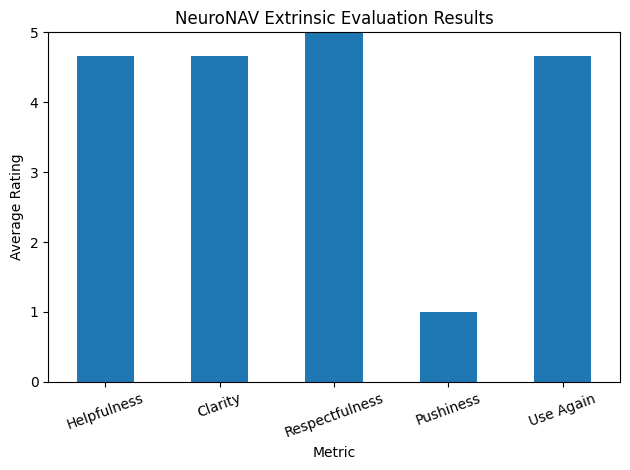

In [7]:
# Get visualization
extrinsic_summary.plot(kind="bar", x="Metric", y="Average Score", legend=False)

plt.title("NeuroNAV Extrinsic Evaluation Results")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Experiment Results

### 1. Intrinsic evaluation: Deficit-language compliance

- **Describe what was evaluated:**  
  This evaluation tested whether NeuroNAV avoided deficit-based, shame-based, or overly pushy language when interacting with users. The evaluation focused on whether the agent used supportive and autonomy-preserving communication instead of imperative or judgmental phrasing.

- **Present the key results (tables, figures, or example outputs):**  
  The evaluation results are shown in the intrinsic evaluation summary table and visualization above. NeuroNAV generally scored well on avoiding deficit-framing language and providing supportive responses.

- **Write at least one conclusion you can draw from the study:**  
  The results suggest that NeuroNAV generally aligns with its goal of using neurodiversity-affirming language. However, some earlier transcripts still included stronger imperative phrasing that could feel pushy to users.

---

### 2. Intrinsic evaluation: Consent-before-transition and scope-match

- **Describe what was evaluated:**  
  This evaluation tested whether NeuroNAV waited for user confirmation before transitioning into schedule-generation behaviors and whether the generated plans matched the actual scope of the user’s request.

- **Present the key results (tables, figures, or example outputs):**  
  The evaluation showed that some transcripts transitioned into schedule or PDF-generation behavior before explicit user confirmation. The evaluation also identified situations where the generated scope became broader than what the user originally requested.

- **Write at least one conclusion you can draw from the study:**  
  The results helped identify important UX issues related to autonomy and scope control. This evaluation demonstrated that NeuroNAV still needs improvements in waiting for user confirmation and preventing inappropriate schedule-generation behavior in unrelated contexts.

---

### 3. Extrinsic evaluation: User study

- **Describe what was evaluated:**  
  The extrinsic evaluation measured whether real users found NeuroNAV helpful, clear, respectful, and non-pushy while completing realistic academic-support tasks.

- **Present the key results (tables, figures, or example outputs):**  
  Three participants completed realistic NeuroNAV interactions and rated the system on helpfulness, clarity, respectfulness, pushiness, and likelihood of using the system again. Overall, NeuroNAV received high scores for helpfulness and respectfulness, while pushiness scores remained low.

- **Write at least one conclusion you can draw from the study:**  
  The user study suggests that NeuroNAV is useful for executive-function support and academic planning tasks. User feedback also suggested that shorter summaries before detailed plans could improve usability.

# Submission

1. Make sure all the important execution results are saved as files and then correctly displayed in whatever file you turn in, in a way that would allow me to grade you without re-running code.
2. Submit a link to your readme and/or evaluation write-up file in your repo (or a google doc)
3. Submit on brightspace a link to your write-up (in markdown in your project github repo, or in this notebook).

**Forgetting about this will result in deduction in the clarity and effort scores.**

Outputs: 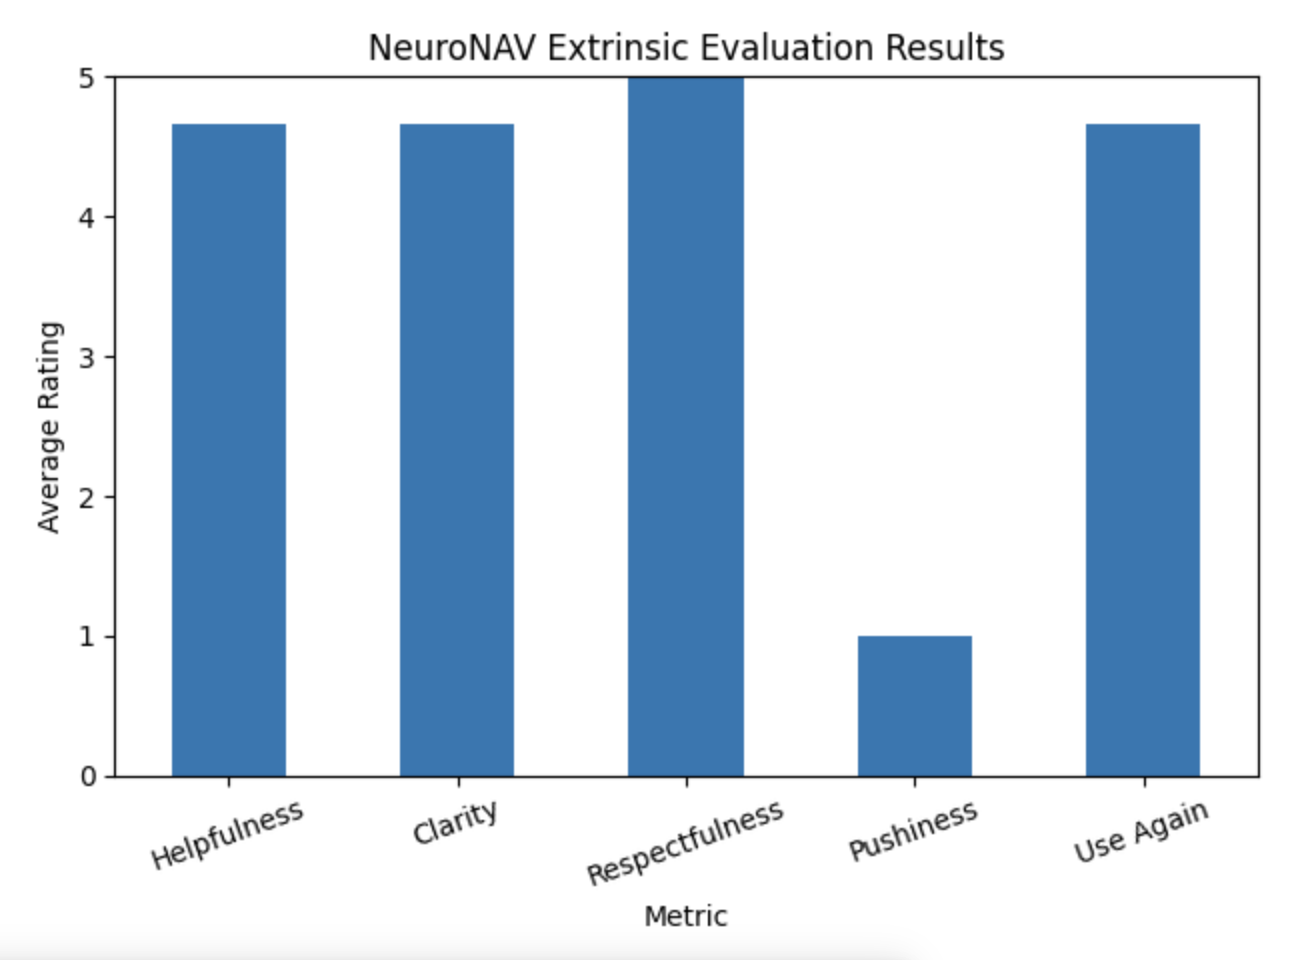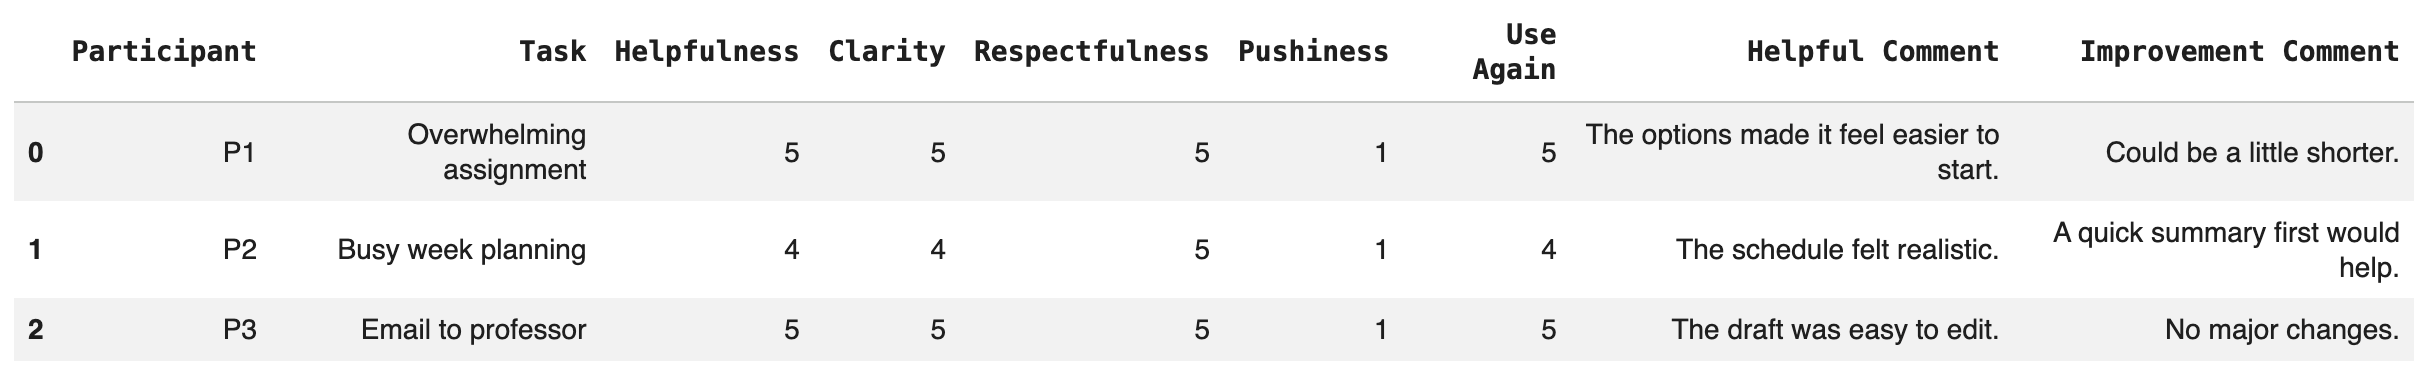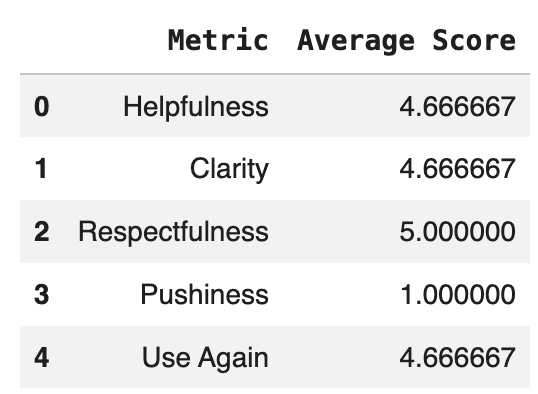